## CPSC 4970 Homework 4 - Jonathan Braun


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
    learning_curve,
    GridSearchCV
)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load and inspect the data

In [37]:
data = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["target", "message"]
)

data.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
print("Data shape:", data.shape)
print()
print(data["target"].value_counts())
print()
print(data.isnull().sum())

Data shape: (5572, 2)

target
ham     4825
spam     747
Name: count, dtype: int64

target     0
message    0
dtype: int64


In [39]:
print("Sample ham messages:")
display(data[data["target"] == "ham"].head())

print("\nSample spam messages:")
display(data[data["target"] == "spam"].head())

Sample ham messages:


,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
6,ham,Even my brother is not like to speak with me. ...



Sample spam messages:


,target,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."


In [40]:
data["target"] = data["target"].map({
    "ham": 0,
    "spam": 1
})

data.head()

data["target"].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

## Train/test split

In [41]:
X = data["message"]
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


## Training data summary

In [42]:
spam_count = y_train.sum()
ham_count = len(y_train) - spam_count
spam_fraction = y_train.mean()

print("Number of spam messages:", spam_count)
print("Number of ham messages:", ham_count)
print(f"Fraction of messages that are spam: {spam_fraction:.4f}")

Number of spam messages: 598
Number of ham messages: 3859
Fraction of messages that are spam: 0.1342


## Trivial-classifier baselines

In [43]:
trivial_predictions = np.zeros(len(y_train), dtype=int)

trivial_accuracy = accuracy_score(y_train, trivial_predictions)
trivial_f1 = f1_score(y_train, trivial_predictions, zero_division=0)

print(f"Trivial classifier accuracy: {trivial_accuracy:.4f}")
print(f"Trivial classifier F1 score: {trivial_f1:.4f}")

Trivial classifier accuracy: 0.8658
Trivial classifier F1 score: 0.0000


## Selected metrics

The two metrics used in this project are accuracy and F1 score, with spam
treated as the positive class.

Accuracy measures the proportion of all messages classified correctly.
However, this dataset is imbalanced because ham messages are much more common
than spam messages. A trivial classifier that always predicts ham achieves an
accuracy of 0.8658 on the training data even though it never detects spam.

F1 score is the second metric because it balances precision and recall for the
positive spam class. It helps determine whether a classifier is actually
identifying spam rather than receiving a high accuracy merely by predicting the
majority class.

The trivial classifier always predicts ham. Its training accuracy baseline is
0.8658, and its F1 score baseline is 0.0000 because it never predicts the
positive spam class.

## Bayesian classifier

In [44]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

bayesian_pipeline = Pipeline([
    (
        "vectorizer",
        CountVectorizer(
            strip_accents="unicode",
            token_pattern=r"(?u)\b[^\W\d_]+\b"
        )
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

bayesian_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b[^\\W\\d_]+\\b'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-gram

## Bayesian training results

In [45]:
bayesian_accuracy_scores = cross_val_score(
    bayesian_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

bayesian_f1_scores = cross_val_score(
    bayesian_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print(
    f"Accuracy: {bayesian_accuracy_scores.mean():.4f} "
    f"+/- {bayesian_accuracy_scores.std():.4f}"
)

print(
    f"F1 score: {bayesian_f1_scores.mean():.4f} "
    f"+/- {bayesian_f1_scores.std():.4f}"
)

Accuracy: 0.9845 +/- 0.0036
F1 score: 0.9413 +/- 0.0137


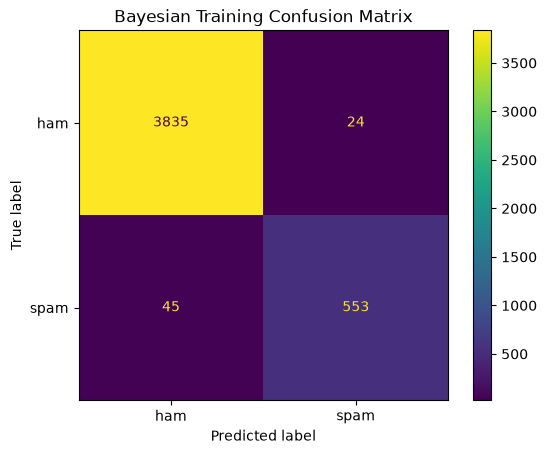

In [46]:
bayesian_training_predictions = cross_val_predict(
    bayesian_pipeline,
    X_train,
    y_train,
    cv=cv
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    bayesian_training_predictions,
    display_labels=["ham", "spam"],
    values_format="d"
)

plt.title("Bayesian Training Confusion Matrix")
plt.show()

In [47]:
bayesian_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b[^\\W\\d_]+\\b'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


## Bayesian testing results

Testing accuracy: 0.9821
Testing F1 score: 0.9306


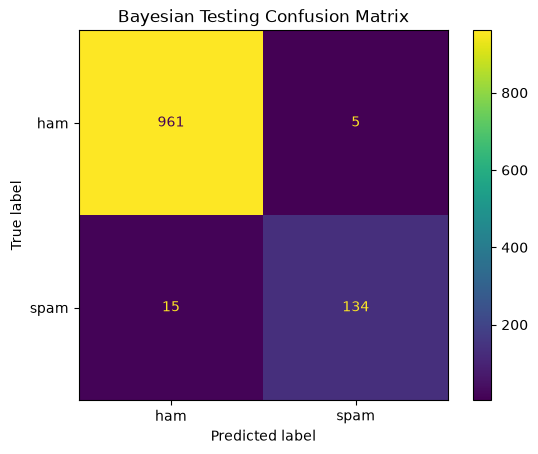

In [48]:
bayesian_test_predictions = bayesian_pipeline.predict(X_test)

bayesian_test_accuracy = accuracy_score(
    y_test,
    bayesian_test_predictions
)

bayesian_test_f1 = f1_score(
    y_test,
    bayesian_test_predictions
)

print(f"Testing accuracy: {bayesian_test_accuracy:.4f}")
print(f"Testing F1 score: {bayesian_test_f1:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    bayesian_test_predictions,
    display_labels=["ham", "spam"],
    values_format="d"
)

plt.title("Bayesian Testing Confusion Matrix")
plt.show()

## Bayesian results discussion

The Bayesian classifier performed substantially better than the trivial
classifier that always predicted ham. The trivial classifier achieved an
accuracy of 0.8658 and an F1 score of 0.0000 because it never identified any
spam messages. In comparison, the Bayesian classifier achieved a testing
accuracy of 0.9821 and a testing F1 score of 0.9306. This indicates that the
Bayesian classifier was able to identify spam effectively rather than simply
benefiting from the larger number of ham messages.

The cross-validation accuracy was 0.9845 +/- 0.0036, giving an approximate
range from 0.9809 to 0.9881. The testing accuracy of 0.9821 was within this
range. The cross-validation F1 score was 0.9413 +/- 0.0137, giving an
approximate range from 0.9276 to 0.9550. The testing F1 score of 0.9306 was
also within this range. Therefore, the testing results were consistent with
the performance observed during cross-validation.

The testing confusion matrix shows that the classifier correctly classified
961 ham messages and 134 spam messages. It incorrectly classified 5 ham
messages as spam and 15 spam messages as ham. This means that relatively few
legitimate messages were incorrectly blocked, although some spam messages
still passed through the filter.

I would consider using this classifier as a starting point for filtering my
own messages because it achieved high accuracy and F1 scores and made relatively
few errors. However, I would not rely on it as the only filtering mechanism
because false positives could hide legitimate messages and some spam messages
were still classified as ham.


## Bayesian training learning curve

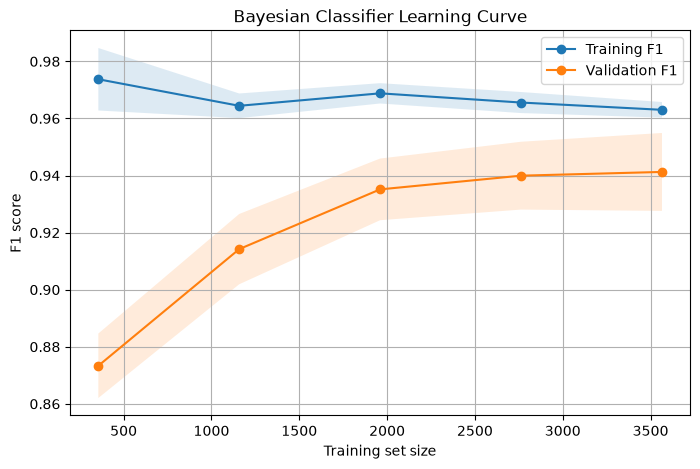

In [49]:
train_sizes, bayesian_train_scores, bayesian_validation_scores = learning_curve(
    bayesian_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

bayesian_train_means = bayesian_train_scores.mean(axis=1)
bayesian_train_stds = bayesian_train_scores.std(axis=1)

bayesian_validation_means = bayesian_validation_scores.mean(axis=1)
bayesian_validation_stds = bayesian_validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    bayesian_train_means,
    marker="o",
    label="Training F1"
)

plt.plot(
    train_sizes,
    bayesian_validation_means,
    marker="o",
    label="Validation F1"
)

plt.fill_between(
    train_sizes,
    bayesian_train_means - bayesian_train_stds,
    bayesian_train_means + bayesian_train_stds,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    bayesian_validation_means - bayesian_validation_stds,
    bayesian_validation_means + bayesian_validation_stds,
    alpha=0.15
)

plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title("Bayesian Classifier Learning Curve")
plt.legend()
plt.grid()
plt.show()

## Bayesian learning-curve discussion

The training F1 score decreases slightly as the training-set size increases,
ending just above 0.96. At the same time, the validation F1 score increases
substantially, rising from approximately 0.87 to just above 0.94. The gap
between the training and validation scores becomes much smaller as more
training examples are added.

The validation score is still increasing at the largest training-set sizes,
although the rate of improvement appears to be slowing. This suggests that the
Bayesian classifier could still benefit from additional labeled SMS messages,
but the gains may become smaller as more data is added.

Therefore, an application that allowed users to label their own messages could
continue improving the classifier over time. Additional labeled data would
likely help the model generalize better, although the learning curve suggests
that the classifier may be approaching a performance plateau.



## Tfidf and a logistic classifier

In [50]:
logistic_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            strip_accents="unicode",
            token_pattern=r"(?u)\b[^\W\d_]+\b"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            max_iter=20000,
            random_state=42
        )
    )
])

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b[^\\W\\d_]+\\b'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps

In [51]:
logistic_parameter_grid = {
    "classifier__l1_ratio": [1.0, 0.0],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "tfidf__use_idf": [True, False]
}

In [52]:
logistic_grid_search = GridSearchCV(
    logistic_pipeline,
    logistic_parameter_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

logistic_grid_search.fit(X_train, y_train)

print("Best parameters:")
print(logistic_grid_search.best_params_)

print(
    f"Best cross-validation F1 score: "
    f"{logistic_grid_search.best_score_:.4f}"
)

Best parameters:
{'classifier__C': 100, 'classifier__l1_ratio': 0.0, 'tfidf__use_idf': True}
Best cross-validation F1 score: 0.9437


## Logistic training results

Accuracy: 0.9854 +/- 0.0028
F1 score: 0.9437 +/- 0.0113


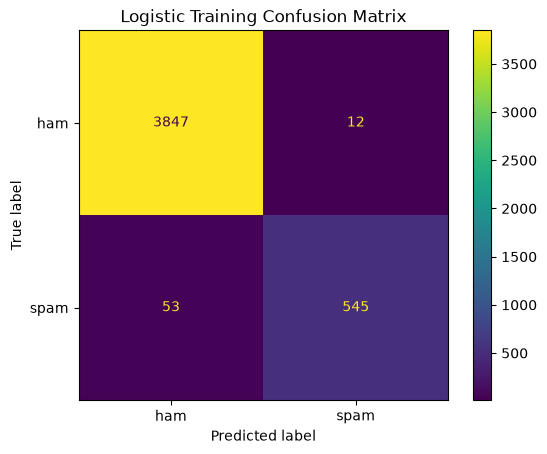

In [53]:
best_logistic_model = logistic_grid_search.best_estimator_

logistic_accuracy_scores = cross_val_score(
    best_logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

logistic_f1_scores = cross_val_score(
    best_logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print(
    f"Accuracy: {logistic_accuracy_scores.mean():.4f} "
    f"+/- {logistic_accuracy_scores.std():.4f}"
)

print(
    f"F1 score: {logistic_f1_scores.mean():.4f} "
    f"+/- {logistic_f1_scores.std():.4f}"
)

logistic_training_predictions = cross_val_predict(
    best_logistic_model,
    X_train,
    y_train,
    cv=cv
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    logistic_training_predictions,
    display_labels=["ham", "spam"],
    values_format="d"
)

plt.title("Logistic Training Confusion Matrix")
plt.show()

## Logistic training learning curve

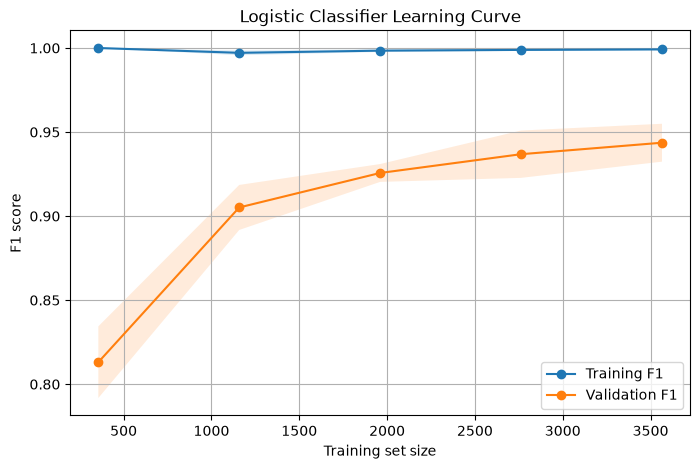

In [54]:
train_sizes, logistic_train_scores, logistic_validation_scores = learning_curve(
    best_logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

logistic_train_means = logistic_train_scores.mean(axis=1)
logistic_train_stds = logistic_train_scores.std(axis=1)

logistic_validation_means = logistic_validation_scores.mean(axis=1)
logistic_validation_stds = logistic_validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    logistic_train_means,
    marker="o",
    label="Training F1"
)

plt.plot(
    train_sizes,
    logistic_validation_means,
    marker="o",
    label="Validation F1"
)

plt.fill_between(
    train_sizes,
    logistic_train_means - logistic_train_stds,
    logistic_train_means + logistic_train_stds,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    logistic_validation_means - logistic_validation_stds,
    logistic_validation_means + logistic_validation_stds,
    alpha=0.15
)

plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title("Logistic Classifier Learning Curve")
plt.legend()
plt.grid()
plt.show()